In [1]:
%load_ext autoreload
%autoreload 2

# Test Forward Process  

In [2]:
from tests.ArProcess import *

ar = AR_normal()
x = ar.generate_trajectory(T= 10000)

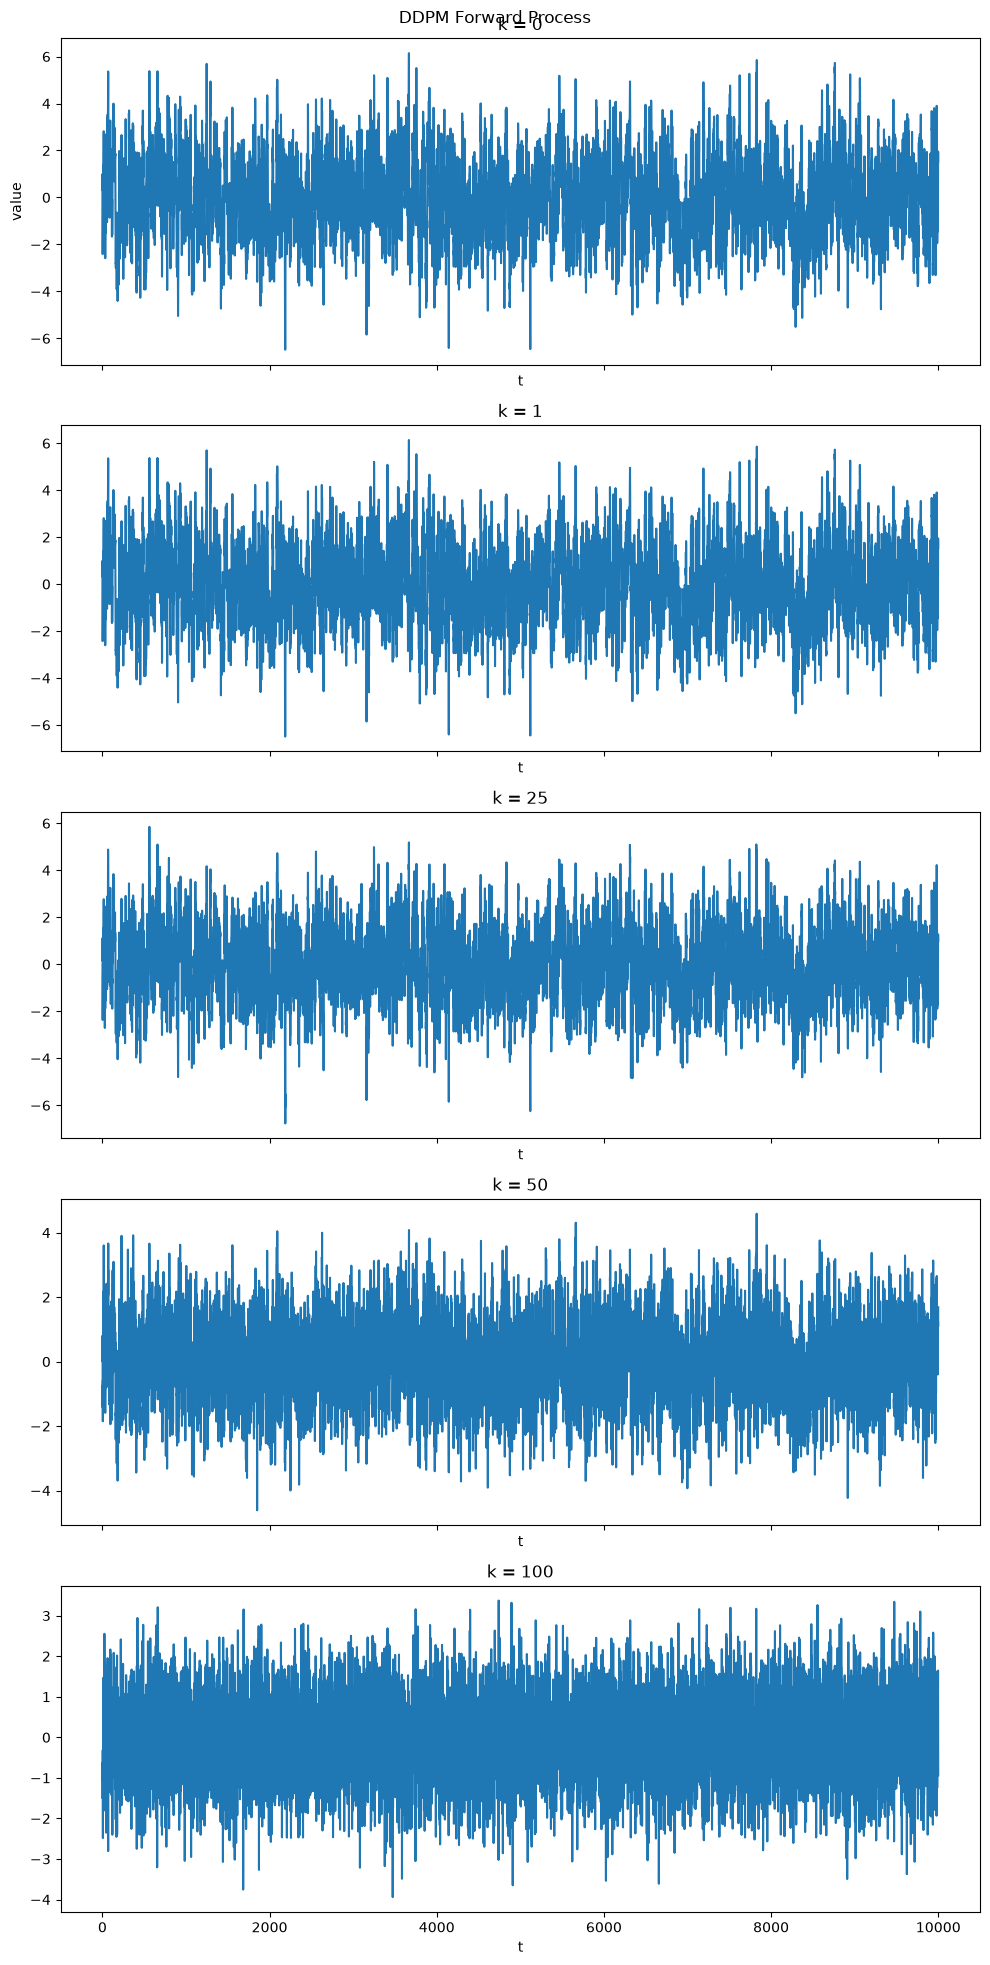

In [27]:
from src.diff.ddpm import DDPM 
from src.diff.scheduler import BaseScheduler
import torch 
import matplotlib.pyplot as plt 

K = 100
scheduler = BaseScheduler(K = K, 
                          beta_1 = 1e-4, 
                          beta_K = 0.1, 
                          mode = 'linear')

ddpm = DDPM(scheduler=scheduler)
k = torch.randint(low = 0, high = K, size=x.shape)

def visualize_forward_process(x: torch.Tensor, steps: list[int] = [1, 25, 50, 100]) -> None:
    """
    Show the forward process noising process

    Parameters
    ----------
        x (torch.Tensor) : original time series process
        steps (list[int]) : list of steps to display. Note that these are the actual step number (i.e. zero in
                            python == step 1 of DDPM)
    """
    paths_dict = {}
    paths_dict['k = 0'] = x
    for k in steps:
        k_torch = torch.ones(size=x.shape, dtype=torch.int64) * (k - 1)
        x_k, _ = ddpm.q_sample(x_0=x, k=k_torch)
        paths_dict[f'k = {k}'] = x_k

    n_plots = len(paths_dict)
    fig, axes = plt.subplots(n_plots, 1, figsize=(10, 4 * n_plots), sharex=True)

    if n_plots == 1:
        axes = [axes]

    for ax, (label, path) in zip(axes, paths_dict.items()):
        series = path.flatten()
        ax.plot(np.arange(0, len(series)), series.flatten().detach().numpy())
        ax.set_title(label)
        ax.set_xlabel('t')

    axes[0].set_ylabel('value')
    fig.suptitle('DDPM Forward Process')
    plt.tight_layout()
    plt.show()

    return paths_dict



paths_dict = visualize_forward_process(x,)


In [26]:
for a in paths_dict.values(): 
    print(a.flatten().detach().cpu().numpy())

[0.31733438 0.99902827 0.59289455 ... 1.9321412  1.955255   1.5387976 ]
[0.3035195  0.98366463 0.6172174  ... 1.9228008  1.956035   1.5443219 ]
[0.24399695 1.9308814  1.5716829  ... 1.3048904  1.5903052  0.87353116]
[ 1.9877192  -0.25476813 -1.3774167  ...  0.9763359   1.5906678
  1.6425014 ]
[-0.42356178  0.55917424  0.10806847 ...  0.89427185  1.0869008
  1.7135392 ]


In [1]:
import torch 


T = 1000
c = torch.randn((T,))
for t in range(1, 1000): 
    c[t] = c[t-1] * 0.7 + torch.randn(1,1)

y = torch.randn_like(c)
for t in range(1, 1000): 
    y[t] = 0.5*y[t-1] + 0.5*c[t-1]

t = torch.linspace(1,100,1000)

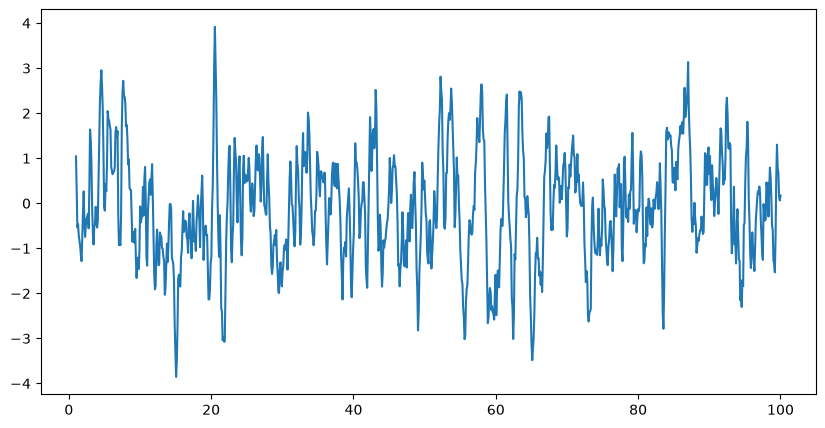

In [2]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,5))
plt.plot(t.detach().numpy(), y.detach().numpy()) 
plt.show()

In [11]:
from TimeGradUtils.diffModules import BaseScheduler, DDPM_TimeGrad
from TimeGradUtils.denoisingRNN import TimeGradRNN_FH, DenoisingNetTimeGrad, TrainSpec
from TimeGradUtils.trainingTg import training_TimeGrad_FH


spec_tg = TrainSpec(t0 = 100,
                    Lookback = 64,
                    batch_size = 64,
                    epochs = 1000,
                    patience = 100,
                    lr = 1e-3,
                    print_loss = False,
                    min_loss= 0.37
                    )

# Diffusion steps, hidden state, lookback
steps = 100
h = 8

linear_scheduler = BaseScheduler(num_train_timesteps = steps, mode = "linear", beta_K=0.1)
timegrad = DDPM_TimeGrad(scheduler=linear_scheduler)


hidden_dim_timegrad = [8,]
time_TimeGrad = []


eModel = DenoisingNetTimeGrad(in_dim = 1, hidden_size = h, dim_hids = [8, 16, 8], num_timesteps = steps)
hModel = TimeGradRNN_FH(input_size=1, hidden_size=h, cell='LSTM')

losses = training_TimeGrad_FH(
    y=y.reshape(-1,1), 
    c = None,
    DeNetmodel = eModel, 
    RNNModel = hModel, 
    diffusion = timegrad, 
    ts = spec_tg
    )

Time to train:  2.2600221633911133
